In [1]:
# ============================================================
# STEP 1 : IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

# Load Dataset
df = pd.read_csv(
    "../data/hotel_bookings (1).csv",
    keep_default_na=False
)

print("Dataset Loaded Successfully")
print("Rows:", len(df))
print("Columns:", len(df.columns))

Dataset Loaded Successfully
Rows: 12000
Columns: 28


In [2]:
# ============================================================
# CUSTOMER LOYALTY TIER ANALYSIS
# ============================================================

loyalty_counts = df['customer_loyalty_tier'].value_counts()

print(loyalty_counts)

customer_loyalty_tier
None        5571
Silver      3135
Gold        2100
Platinum    1194
Name: count, dtype: int64


In [3]:
# ============================================================
# CUSTOMER SEGMENT ANALYSIS
# ============================================================

segment_counts = df['customer_segment'].value_counts()

print(segment_counts)

customer_segment
Individual    7700
Corporate     2892
Group         1408
Name: count, dtype: int64


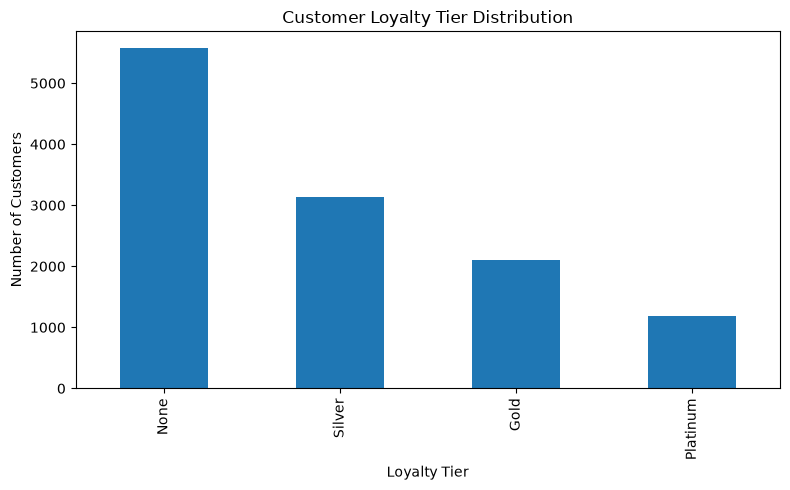

In [4]:
# ============================================================
# LOYALTY TIER DISTRIBUTION
# ============================================================

plt.figure(figsize=(8,5))

df['customer_loyalty_tier'].value_counts().plot(
    kind='bar'
)

plt.title('Customer Loyalty Tier Distribution')
plt.xlabel('Loyalty Tier')
plt.ylabel('Number of Customers')

plt.tight_layout()

plt.savefig(
    '../outputs/charts/customer_loyalty_distribution.png'
)

plt.show()

## Business Insight - Customer Loyalty Tier Distribution

### Key Findings

- Nearly half of all bookings come from customers with no loyalty tier membership.
- Silver tier represents the largest enrolled loyalty segment.
- Gold and Platinum customers form a smaller but highly valuable customer base.

### Business Interpretation

- A large number of customers are not enrolled in the loyalty program.
- This presents an opportunity to improve customer retention through loyalty enrollment campaigns.
- Gold and Platinum members should be targeted with premium offers and personalized experiences.

### Recommendation

- Introduce incentives to convert non-members into Silver tier customers.
- Create exclusive benefits for Gold and Platinum customers to increase repeat bookings.

In [8]:
df['customer_loyalty_tier'].value_counts()

customer_loyalty_tier
None        5571
Silver      3135
Gold        2100
Platinum    1194
Name: count, dtype: int64

In [9]:
df['customer_segment'].value_counts()

customer_segment
Individual    7700
Corporate     2892
Group         1408
Name: count, dtype: int64

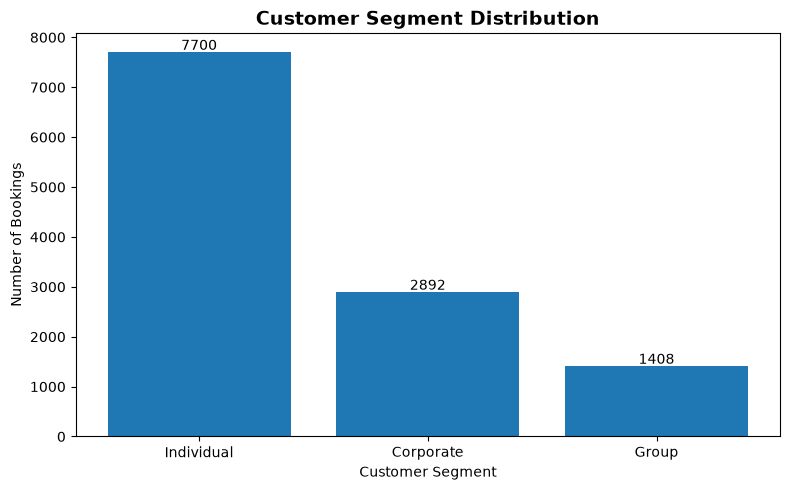

In [10]:
# ============================================================
# CUSTOMER SEGMENT DISTRIBUTION
# ============================================================

segment_counts = df['customer_segment'].value_counts()

plt.figure(figsize=(8,5))

bars = plt.bar(
    segment_counts.index,
    segment_counts.values
)

plt.title(
    'Customer Segment Distribution',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Customer Segment')
plt.ylabel('Number of Bookings')

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 50,
        int(bar.get_height()),
        ha='center'
    )

plt.tight_layout()

plt.savefig(
    '../outputs/charts/customer_segment_distribution.png',
    dpi=300
)

plt.show()

## Business Insight - Customer Segment Distribution

### Key Findings

- Individual customers account for the majority of bookings.
- Corporate customers form the second largest segment.
- Group bookings represent the smallest customer segment.

### Business Interpretation

- The platform is heavily dependent on individual travelers.
- Corporate customers represent a strong growth opportunity.
- Group travel packages can be promoted to increase booking volume.

### Recommendation

- Strengthen partnerships with corporate clients.
- Launch special offers for group bookings.
- Continue investing in individual customer acquisition.

In [11]:
# ============================================================
# TOP 10 HIGH VALUE CUSTOMERS
# ============================================================

top_customers = (
    df.groupby('customer_id')['total_amount']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

print(top_customers)

customer_id
737    2077948.97
493    1901788.78
681    1817198.56
496    1762998.41
28     1761947.02
428    1732552.25
123    1716996.79
502    1707925.06
255    1682531.49
143    1632693.75
Name: total_amount, dtype: float64


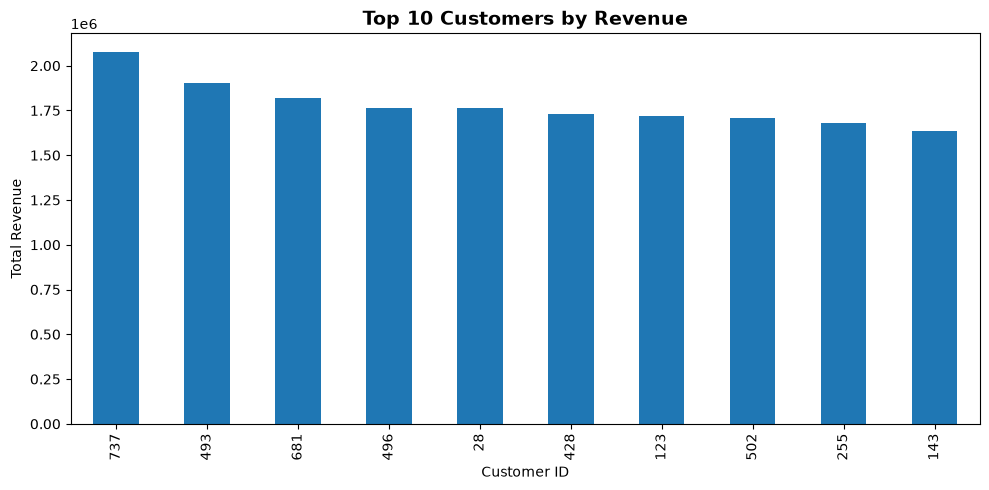

In [12]:
# ============================================================
# TOP 10 CUSTOMERS BY REVENUE
# ============================================================

plt.figure(figsize=(10,5))

top_customers.plot(
    kind='bar'
)

plt.title(
    'Top 10 Customers by Revenue',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Customer ID')
plt.ylabel('Total Revenue')

plt.tight_layout()

plt.savefig(
    '../outputs/charts/top_customers_revenue.png',
    dpi=300
)

plt.show()

# Business Insight - Top 10 Customers by Revenue

## Key Findings

- Customer 737 generated the highest revenue of approximately ₹20.78 lakh.
- The top 10 customers each generated more than ₹16 lakh in total revenue.
- Revenue contribution among the top customers is relatively balanced, with no single customer dominating the entire revenue base.

## Business Interpretation

- A small group of customers contributes significantly to total platform revenue.
- These customers represent high-value VIP customers and should be prioritized for retention.
- Losing even a few of these customers could have a measurable impact on overall revenue.

## Recommendations

- Introduce a VIP loyalty program for top revenue-generating customers.
- Offer personalized discounts, upgrades, and early-access deals.
- Monitor booking behavior of these customers and proactively prevent churn.

In [13]:
top_customers = (
    df.groupby('customer_id')['total_amount']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

print(top_customers)

customer_id
737    2077948.97
493    1901788.78
681    1817198.56
496    1762998.41
28     1761947.02
428    1732552.25
123    1716996.79
502    1707925.06
255    1682531.49
143    1632693.75
Name: total_amount, dtype: float64


In [14]:
# ============================================================
# REVENUE BY LOYALTY TIER
# ============================================================

revenue_tier = (
    df.groupby('customer_loyalty_tier')['total_amount']
      .sum()
      .sort_values(ascending=False)
)

print(revenue_tier)

customer_loyalty_tier
None        1.731694e+08
Silver      9.610823e+07
Gold        6.520582e+07
Platinum    4.127833e+07
Name: total_amount, dtype: float64


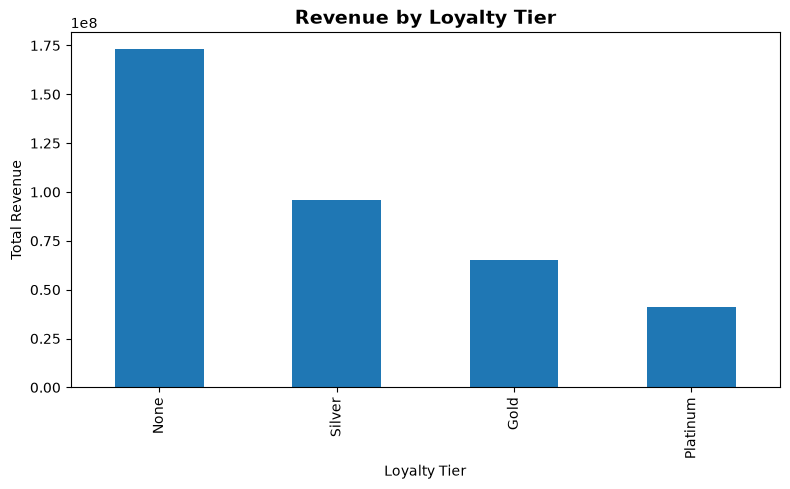

In [15]:
# ============================================================
# REVENUE BY LOYALTY TIER
# ============================================================

plt.figure(figsize=(8,5))

revenue_tier.plot(
    kind='bar'
)

plt.title(
    'Revenue by Loyalty Tier',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Loyalty Tier')
plt.ylabel('Total Revenue')

plt.tight_layout()

plt.savefig(
    '../outputs/charts/revenue_by_loyalty_tier.png',
    dpi=300
)

plt.show()

# Business Insight - Revenue by Loyalty Tier

## Key Findings

- Customers without loyalty membership generated the highest total revenue.
- Silver tier customers contributed the second-highest revenue.
- Gold and Platinum tiers generated lower total revenue due to smaller customer populations.

## Business Interpretation

- A significant share of revenue comes from customers who are not enrolled in the loyalty program.
- The organization may be missing opportunities to improve retention and repeat bookings through membership benefits.
- Revenue concentration among non-members suggests potential for loyalty program expansion.

## Recommendations

- Target high-spending non-members with loyalty enrollment campaigns.
- Offer personalized rewards to encourage membership upgrades.
- Analyze booking frequency of non-members to identify VIP conversion opportunities.

In [16]:
# ============================================================
# REVENUE BY CUSTOMER SEGMENT
# ============================================================

segment_revenue = (
    df.groupby('customer_segment')['total_amount']
      .sum()
      .sort_values(ascending=False)
)

print(segment_revenue)

customer_segment
Individual    1.667543e+08
Corporate     1.103323e+08
Group         9.867513e+07
Name: total_amount, dtype: float64


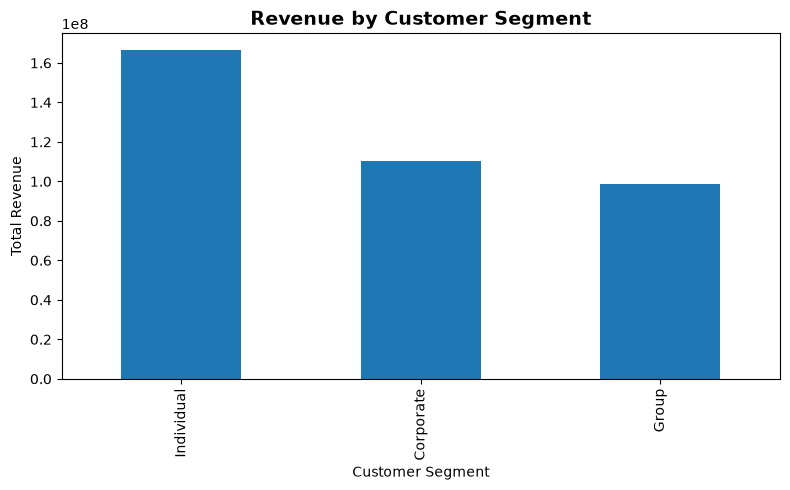

In [17]:
# ============================================================
# REVENUE BY CUSTOMER SEGMENT
# ============================================================

plt.figure(figsize=(8,5))

segment_revenue.plot(
    kind='bar'
)

plt.title(
    'Revenue by Customer Segment',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Customer Segment')
plt.ylabel('Total Revenue')

plt.tight_layout()

plt.savefig(
    '../outputs/charts/revenue_by_customer_segment.png',
    dpi=300
)

plt.show()

# Business Insight - Revenue by Customer Segment

## Key Findings

- Individual customers generated the highest total revenue at approximately ₹166.75 Million.
- Corporate customers contributed more than ₹110 Million in revenue.
- Group bookings generated nearly ₹99 Million in revenue.

## Business Interpretation

- Individual customers are the primary revenue driver for the platform.
- Corporate bookings represent a significant and stable revenue stream.
- Group bookings also contribute substantially and should not be overlooked.

## Recommendations

- Continue investing in customer acquisition and retention strategies for individual travelers.
- Strengthen partnerships with corporate clients through negotiated rates and loyalty programs.
- Create customized packages and discounts for group travelers to increase booking volume.

In [18]:
# ============================================================
# TOP REVENUE GENERATING CITIES
# ============================================================

city_revenue = (
    df.groupby('property_city')['total_amount']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

print(city_revenue)

property_city
Chennai      66117302.25
Goa          63375499.74
Bangalore    57494205.40
Udaipur      51626744.78
Mumbai       46269798.85
Pune         40993365.43
Kochi        17787045.28
Delhi        15920403.28
Manali       12865678.92
Jaipur        3311707.31
Name: total_amount, dtype: float64


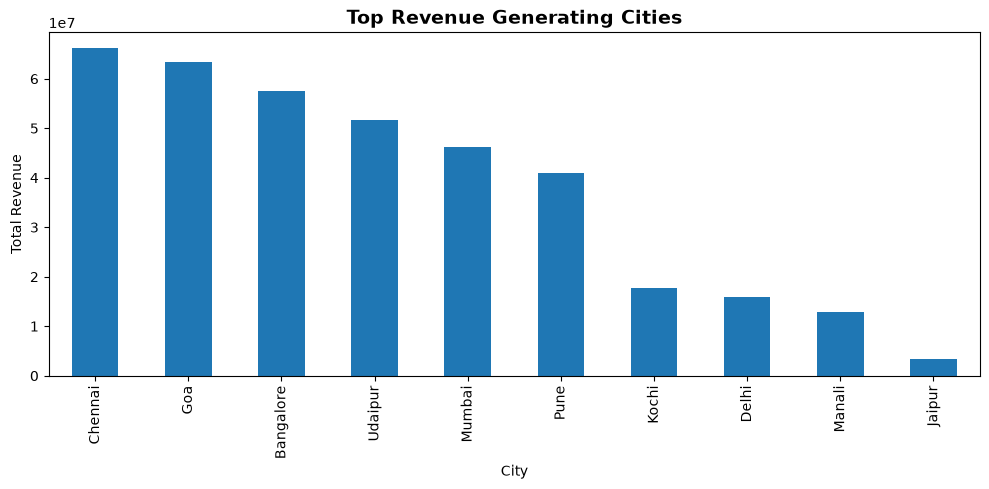

In [19]:
# ============================================================
# TOP REVENUE GENERATING CITIES
# ============================================================

plt.figure(figsize=(10,5))

city_revenue.plot(
    kind='bar'
)

plt.title(
    'Top Revenue Generating Cities',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('City')
plt.ylabel('Total Revenue')

plt.tight_layout()

plt.savefig(
    '../outputs/charts/top_revenue_cities.png',
    dpi=300
)

plt.show()


# Business Insight - Top Revenue Generating Cities

## Key Findings

- Chennai generated the highest revenue among all cities.
- Goa and Bangalore also contributed significantly to overall platform revenue.
- The top 5 cities account for the majority of total revenue generated.

## Business Interpretation

- Revenue is concentrated in a few high-performing destinations.
- Chennai and Goa appear to be strategic markets with strong customer demand.
- Lower-performing cities may require targeted marketing initiatives to improve booking volumes.

## Recommendations

- Increase marketing investments in Chennai, Goa, and Bangalore to maximize returns.
- Explore expansion opportunities in top-performing cities.
- Conduct demand analysis for lower-performing locations to identify growth opportunities.

In [20]:
avg_revenue = (
    df.groupby('customer_segment')['total_amount']
      .mean()
      .sort_values(ascending=False)
)

print(avg_revenue)

customer_segment
Group         70081.768139
Corporate     38150.869018
Individual    21656.403701
Name: total_amount, dtype: float64


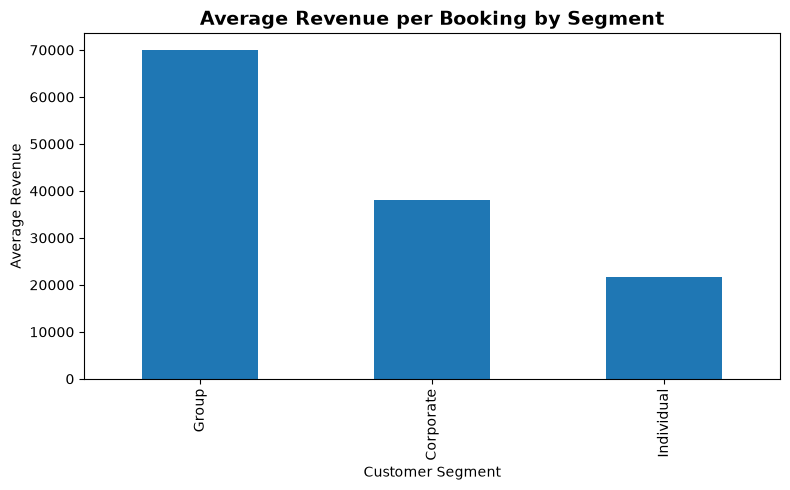

In [21]:
# ============================================================
# AVERAGE REVENUE PER BOOKING BY CUSTOMER SEGMENT
# ============================================================

plt.figure(figsize=(8,5))

avg_revenue.plot(
    kind='bar'
)

plt.title(
    'Average Revenue per Booking by Segment',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Customer Segment')
plt.ylabel('Average Revenue')

plt.tight_layout()

plt.savefig(
    '../outputs/charts/avg_revenue_per_segment.png',
    dpi=300
)

plt.show()

# Business Insight - Average Revenue per Booking

## Key Findings

- Group bookings generated the highest average revenue per booking.
- Corporate bookings generated the second-highest average revenue.
- Individual bookings generated the lowest average revenue per booking despite contributing the highest total revenue.

## Business Interpretation

- Group travelers represent the highest-value customer segment on a per-booking basis.
- Corporate customers also contribute significant value through larger booking sizes.
- Individual customers drive booking volume, while Group and Corporate customers drive profitability.

## Recommendations

- Develop special packages for group travelers.
- Expand corporate travel partnerships and negotiated pricing agreements.
- Maintain acquisition efforts for individual customers while focusing premium marketing efforts on high-value segments.

In [23]:
cancel_channel = pd.crosstab(
    df['booking_channel'],
    df['booking_status'],
    normalize='index'
) * 100

print(cancel_channel)

booking_status    Cancelled  Completed   No-Show
booking_channel                                 
Corporate Portal  20.230314  76.470588  3.299097
Direct Website    14.849624  82.142857  3.007519
OTA               22.073027  74.911661  3.015312
Travel Agent      16.528583  80.695940  2.775476


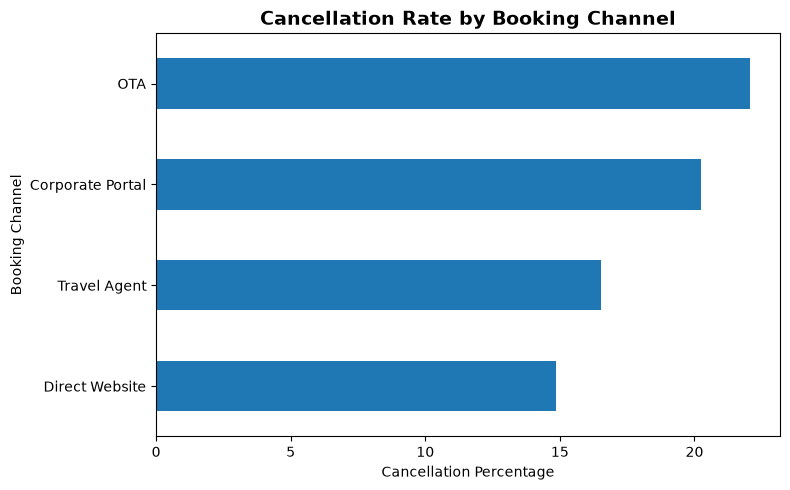

In [24]:
# ============================================================
# CANCELLATION RATE BY BOOKING CHANNEL
# ============================================================

cancel_channel = pd.crosstab(
    df['booking_channel'],
    df['booking_status'],
    normalize='index'
) * 100

cancel_channel['Cancelled'].sort_values().plot(
    kind='barh',
    figsize=(8,5)
)

plt.title(
    'Cancellation Rate by Booking Channel',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Cancellation Percentage')
plt.ylabel('Booking Channel')

plt.tight_layout()

plt.savefig(
    '../outputs/charts/cancellation_by_channel.png',
    dpi=300
)

plt.show()

# Business Insight - Cancellation Rate by Booking Channel

## Key Findings

- OTA bookings show the highest cancellation rate.
- Direct Website bookings have the lowest cancellation rate.
- Corporate Portal and Travel Agent channels perform better than OTA channels.

## Business Interpretation

- OTA customers appear more likely to cancel reservations.
- Direct Website customers demonstrate stronger booking commitment.
- High OTA cancellation rates can create revenue forecasting challenges and inventory inefficiencies.

## Recommendations

- Increase focus on direct booking channels.
- Offer loyalty benefits for website bookings.
- Investigate cancellation reasons among OTA customers.
- Implement targeted retention campaigns for OTA customers.

In [25]:
# ============================================================
# REPEAT CUSTOMER ANALYSIS
# ============================================================

repeat_customers = (
    df.groupby('customer_id')['booking_id']
      .count()
)

print("Customers with Multiple Bookings:")
print((repeat_customers > 1).sum())

print("\nRepeat Customer Percentage:")
print(
    round(
        ((repeat_customers > 1).sum() /
         repeat_customers.count()) * 100,
        2
    ),
    "%"
)

Customers with Multiple Bookings:
800

Repeat Customer Percentage:
100.0 %


# Final Executive Summary

## Objective
Identify high-value customer segments and revenue-driving patterns to support business growth.

## Key Insights

1. Nearly 46% of bookings come from customers without loyalty membership.
2. Individual customers generate the highest overall revenue.
3. Group customers generate the highest average revenue per booking.
4. Chennai, Goa, and Bangalore are the top revenue-generating cities.
5. A small set of customers contributes significantly to total revenue.
6. OTA channels show the highest cancellation rates.

## Business Recommendations

- Expand loyalty program enrollment among non-members.
- Focus marketing investments on Chennai, Goa, and Bangalore.
- Develop premium offerings for Gold and Platinum customers.
- Strengthen retention efforts for high-value customers.
- Reduce OTA cancellation rates through targeted interventions.

## Conclusion

The analysis highlights clear opportunities to increase revenue through customer retention, loyalty program expansion, targeted city-level marketing, and cancellation reduction strategies.